In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# 导数基础

In [2]:
def f(x):
    return 3 * x ** 2 - 4 * x + 5

In [3]:
f(3.0)

20.0

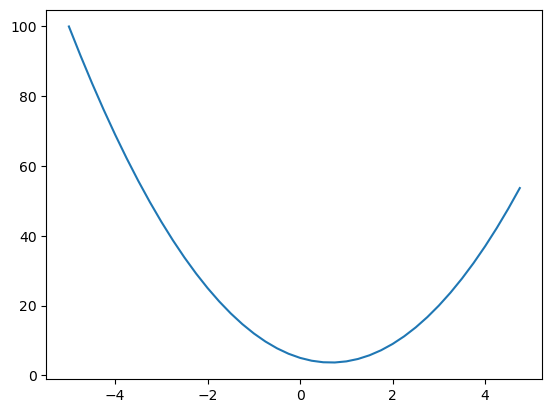

In [7]:
xs = np.arange(-5, 5, 0.25)
ys = f(xs)

plt.plot(xs, ys)
plt.show()

In [ ]:
h = 0.0001
x = 3.0
t = (f(x + h) - f(x)) / h
t

14.000300000063248

In [12]:
h = 0.00001
a = 2.0
b = -3.0
c = 10

d1 = a * b + c
b += h
d2 = a * b + c
t = (d2 - d1) / h
t

2.0000000000131024

# 引入神经网络

In [44]:
from graphviz import Digraph

def trace(root):
    # build a set of all nodes and edges in the graph
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'})  # LR = left to right

    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        # for any value in the graph, create a rectangle ('record') node for it
        dot.node(name = uid, label = '{ %s | data %.4f }' % (n._label, n.data, ), shape='record')
        if n._op:
            # if this value is the result of some operation, create an op node for it
            dot.node(name = uid + n._op, label = n._op)
            # and connect the operation to its inputs
            dot.edge(uid + n._op, uid)

    for n1, n2 in edges:
        # connect n1 to the op node of n2
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)

    return dot

In [41]:
class Value:

    def __init__(self, data, _children=(), _op='', _label=''):
        self.data = data
        self._prev = set(_children)
        self._op = _op
        self._label = _label

    def __repr__(self):
        return f"Value(data={self.data})"

    def __add__(self, other):
        return Value(self.data + other.data, (self, other), '+')

    def __mul__(self, other):
        return Value(self.data * other.data, (self, other), '*')


In [56]:
a = Value(2.0, _label='a')
b = Value(-3.0, _label='b')
c = a * b; c._label = 'c'
d = Value(10.0, _label='d')
e = c + d; e._label = 'e'
f = Value(-2.0, _label='f')
L = e * f; L._label = 'L'


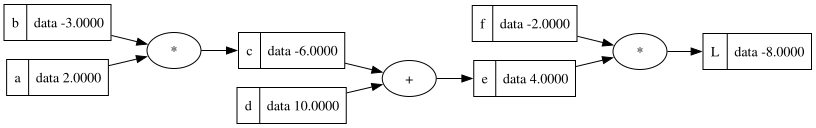

In [57]:
draw_dot(L)